# Traffic Sign Classification with a Convolutional neural network

This notebook implements a clean final pipeline for the German Traffic Sign Recognition Benchmark (GTSRB), which is based on the long version, where all my experiments are recorded.  
The goal is supervised multi-class classification of cropped traffic-sign images into 43 classes.

The notebook contains only the final selected model pipeline:

1. Load and validate the dataset
2. Perform concise exploratory analysis
3. Preprocess images and labels
4. Train the final compact VGG-style CNN
5. Evaluate with accuracy, macro F1, weighted F1, confusion matrix, class-wise metrics, and error analysis

The final model uses normalized `32 × 32` RGB images, light photometric augmentation, batch normalization, dropout, global average pooling, RMSprop and learning-rate decay.

## 1. Imports and configuration

All important settings are placed in one cell to make the experiment easy to reproduce and modify.

In [44]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import ( accuracy_score, f1_score, classification_report, confusion_matrix)


# Reproducibility

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Main configuration
IMG_SIZE = (32, 32)
NUM_CLASSES = 43
BATCH_SIZE = 64
EPOCHS = 20
VALIDATION_SIZE = 0.20

# Change this path if the dataset is stored somewhere else.
DATASET_PATH = Path("/Users/raresolteanu/Desktop/2026_Practical_Deep_learning_EIM12OB001/archive-2")

TRAIN_CSV = DATASET_PATH / "Train.csv"
TEST_CSV = DATASET_PATH / "Test.csv"
META_CSV = DATASET_PATH / "Meta.csv"

print("TensorFlow version:", tf.__version__)
print("Dataset path:", DATASET_PATH)

TensorFlow version: 2.16.2
Dataset path: /Users/raresolteanu/Desktop/2026_Practical_Deep_learning_EIM12OB001/archive-2


## 2. Dataset Loading

The dataset is loaded using the official CSV annotation files provided with GTSRB.  
Each entry contains the relative path to an image and its corresponding class label.

Images are:
- Loaded from disk using the provided paths
- Resized to **32 × 32 pixels** to ensure computational efficiency
- Converted to **RGB format** for consistency across the dataset

To maintain consistency with the course materials, class names are imported from the the py file that the professor provided (`traffic_sign_load.py`), ensuring alignment with the official label definitions.

In [ ]:
# Py file path that help us import the class names and dataset
project_path = DATASET_PATH.parent / "Individual_projects"

if project_path.exists() and str(project_path) not in sys.path:
    sys.path.append(str(project_path))

import traffic_sign_load

class_names = [traffic_sign_load.CLASS_NAMES[i] for i in range(NUM_CLASSES)]

assert len(class_names) == NUM_CLASSES
print("Number of classes:", len(class_names))
print("Example class:", class_names[0])

Number of classes: 43
Example class: Speed limit (20)


## 3. Data Loading and Validation

Before loading the dataset, a validation step is performed to ensure that all required files and directories are available. This includes checking the existence of:
- The dataset root folder
- Training and test image directories
- CSV annotation files

Images are then loaded using a custom function that:
- Reads image paths and labels from the CSV files
- Converts images to **RGB format**
- Resizes them to **32 × 32 pixels** (This was used to make sure that even if the images are labeled as 32 x 32 by the dataset, there is not image that exceed the size)
- Stores them as NumPy arrays for efficient processing

A progress indicator is included to monitor loading for large datasets.

This approach ensures that the dataset is correctly structured, prevents runtime errors due to missing files and provides a reproducible and controlled data-loading pipeline.

In [19]:
def check_dataset_paths():
    required_paths = [
        DATASET_PATH,
        DATASET_PATH / "Train",
        DATASET_PATH / "Test",
        TRAIN_CSV,
        TEST_CSV,
    ]

    missing = [str(path) for path in required_paths if not path.exists()]

    if missing:
        raise FileNotFoundError(
            "Missing dataset files/folders:\n"
            + "\n".join(missing)
            + "\n\nPlease update DATASET_PATH in the configuration cell."
        )


def load_images_from_csv(df, dataset_root, image_size=(32, 32), show_progress_every=5000):
    images = np.empty((len(df), image_size[0], image_size[1], 3), dtype=np.uint8)
    labels = np.empty(len(df), dtype=np.int64)

    for i, row in enumerate(df.itertuples(index=False)):
        image_relative_path = str(row.Path).replace("\\", "/")
        image_path = Path(dataset_root) / image_relative_path

        image = Image.open(image_path).convert("RGB")
        image = image.resize(image_size)

        images[i] = np.asarray(image, dtype=np.uint8)
        labels[i] = int(row.ClassId)

        if (i + 1) % show_progress_every == 0 or (i + 1) == len(df):
            print(f"Loaded {i + 1}/{len(df)} images")

    return images, labels


check_dataset_paths()

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train CSV shape:", train_df.shape)
print("Test CSV shape:", test_df.shape)

X_full_uint8, y_full = load_images_from_csv(train_df, DATASET_PATH, IMG_SIZE)
X_test_uint8, y_test = load_images_from_csv(test_df, DATASET_PATH, IMG_SIZE)

print("Training images:", X_full_uint8.shape)
print("Test images:", X_test_uint8.shape)

Train CSV shape: (39209, 8)
Test CSV shape: (12630, 8)
Loaded 5000/39209 images
Loaded 10000/39209 images
Loaded 15000/39209 images
Loaded 20000/39209 images
Loaded 25000/39209 images
Loaded 30000/39209 images
Loaded 35000/39209 images
Loaded 39209/39209 images
Loaded 5000/12630 images
Loaded 10000/12630 images
Loaded 12630/12630 images
Training images: (39209, 32, 32, 3)
Test images: (12630, 32, 32, 3)


## 4. Concise Exploratory Data Analysis

This section provides a brief exploratory analysis of the dataset to understand its key characteristics before model training.

First, a small set of random training images is displayed to visually inspect the data. This helps verify that:
- Images are correctly loaded and preprocessed
- Labels correspond to the expected traffic sign categories
- Visual variability (lighting, angle, scale) is present

Next, the class distribution is analyzed by counting the number of samples per class. This reveals that the dataset is **imbalanced**, with some classes having significantly more samples than others.

To quantify this, both the absolute number of images and the relative frequency (%) are computed for each class. A bar plot is used to visualize the distribution.

This analysis is important because:
- Class imbalance can bias the model toward frequent classes
- Accuracy alone may be misleading
- It motivates the use of **macro F1** and **weighted F1** as evaluation metrics

Overall, this step ensures that the dataset is well understood and that the evaluation strategy is aligned with its statistical properties.

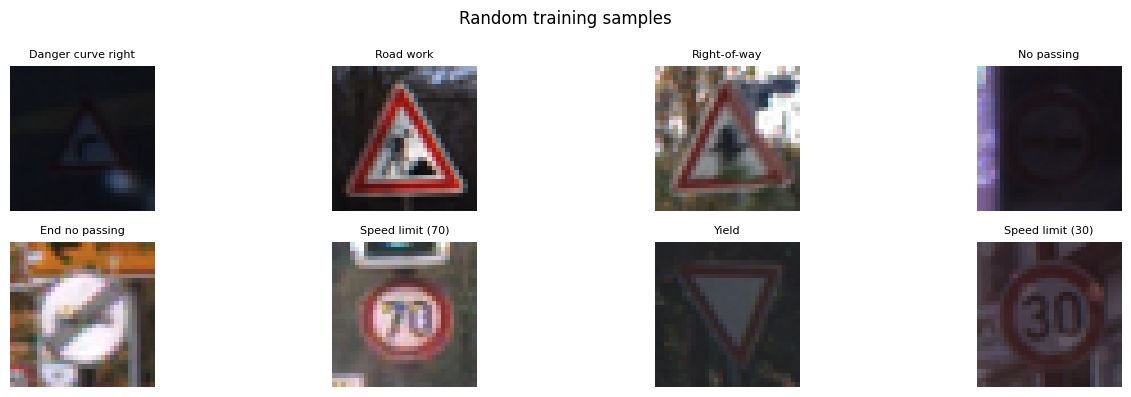

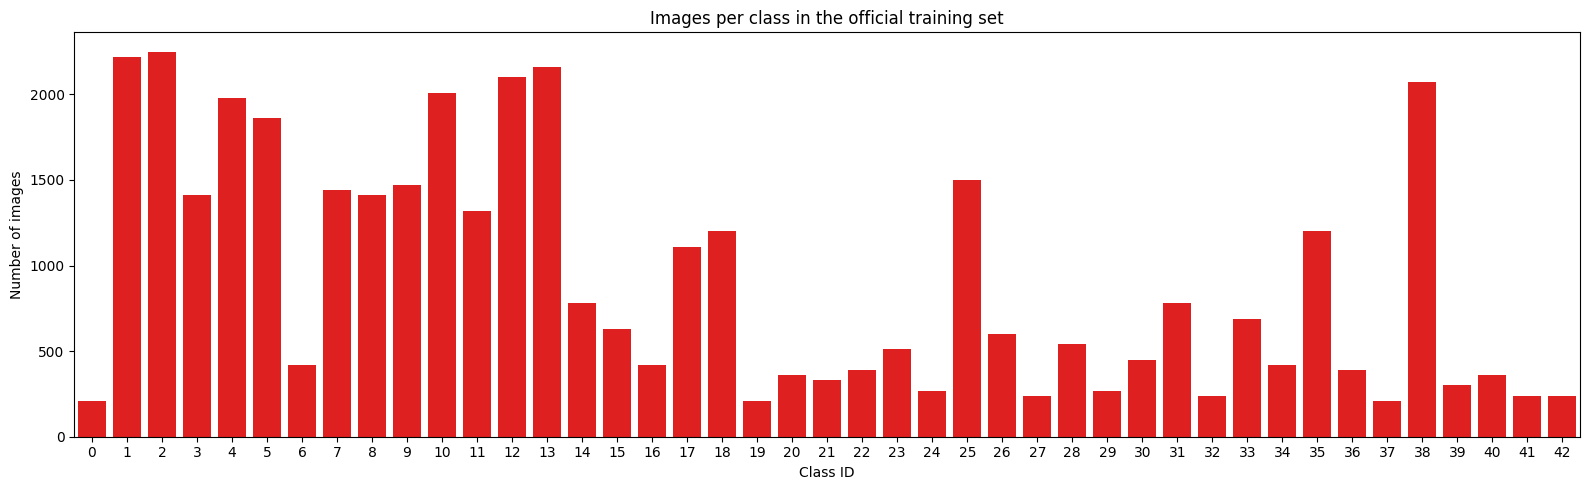

,ClassId,Image Count,Class Name,Frequency (%)
0,0,210,Speed limit (20),0.535591
37,37,210,Go straight/left,0.535591
19,19,210,Danger curve left,0.535591
32,32,240,End speed+passing,0.612104
27,27,240,Pedestrians,0.612104
41,41,240,End no passing,0.612104
42,42,240,End no passing >3.5t,0.612104
24,24,270,Road narrows,0.688617
29,29,270,Bicycles crossing,0.688617
39,39,300,Keep left,0.765130


In [43]:
sample_indices = random.sample(range(len(X_full_uint8)), 8)

plt.figure(figsize=(14, 4))
for plot_index, image_index in enumerate(sample_indices):
    plt.subplot(2, 4, plot_index + 1)
    plt.imshow(X_full_uint8[image_index])
    plt.title(class_names[y_full[image_index]], fontsize=8)
    plt.axis("off")

plt.suptitle("Random training samples")
plt.tight_layout()
plt.show()


class_count_df = (
    pd.Series(y_full)
    .value_counts()
    .sort_index()
    .reset_index()
)

class_count_df.columns = ["ClassId", "Image Count"]
class_count_df["Class Name"] = class_count_df["ClassId"].map(lambda x: class_names[x])
class_count_df["Frequency (%)"] = 100 * class_count_df["Image Count"] / len(y_full)

plt.figure(figsize=(16, 5))
sns.barplot(data=class_count_df, x="ClassId", y="Image Count", color= 'red')
plt.title("Images per class in the official training set")
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

class_count_df.sort_values("Image Count").head(10)

## 5. Train–Validation Split and Leakage Check

The official test set is kept strictly separate and is used only for final evaluation.

The training data is split into training and validation subsets using a **stratified split**, ensuring that class distributions are preserved across both sets.

To prevent data leakage, a hash-based duplicate check is performed between:
- Training images and the official test set
- Validation images and the official test set

Each image is converted into a unique hash using its pixel values. Any exact overlaps are removed from the training and validation sets.

This step is important because:
- Even a small number of duplicates can artificially inflate performance
- It ensures a fair and unbiased evaluation on the test set

Finally, the shapes of the resulting datasets are printed to confirm correctness.

In [22]:
import hashlib


def image_hash(image_array):
    """Compute a hash for an image using its raw pixel values."""
    return hashlib.md5(image_array.tobytes()).hexdigest()


def remove_test_overlaps(X_train, y_train, X_val, y_val, X_test):
    """Remove exact duplicates between train/val and test sets."""

    # Precompute test hashes, this is faster than recomputing each time
    test_hashes = {image_hash(img) for img in X_test}

    # Create masks
    train_keep = np.array([image_hash(img) not in test_hashes for img in X_train])
    val_keep = np.array([image_hash(img) not in test_hashes for img in X_val])

    # Logging
    print(f"Exact train/test overlaps removed: {np.sum(~train_keep)}")
    print(f"Exact validation/test overlaps removed: {np.sum(~val_keep)}")

    return (
        X_train[train_keep],
        y_train[train_keep],
        X_val[val_keep],
        y_val[val_keep],
    )


# Stratified split
X_train_uint8, X_val_uint8, y_train, y_val = train_test_split(
    X_full_uint8,
    y_full,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_full,
)


# Remove overlaps
X_train_uint8, y_train, X_val_uint8, y_val = remove_test_overlaps(
    X_train_uint8,
    y_train,
    X_val_uint8,
    y_val,
    X_test_uint8,
)
# Final shapes to check the shapes
print("Final train shape:", X_train_uint8.shape)
print("Final validation shape:", X_val_uint8.shape)
print("Final test shape:", X_test_uint8.shape)

Exact train/test overlaps removed: 3
Exact validation/test overlaps removed: 5
Final train shape: (31364, 32, 32, 3)
Final validation shape: (7837, 32, 32, 3)
Final test shape: (12630, 32, 32, 3)


## 6. Preprocessing and TensorFlow Dataset Pipeline

Before training, images are converted from integer pixel values to floating-point tensors and normalized to the range **[0, 1]**. This improves numerical stability during gradient-based optimization.

Labels are one-hot encoded because the model uses a **softmax output layer** with **categorical cross-entropy loss**.

A TensorFlow `Dataset` pipeline is then created for efficient training:
- The training set is shuffled to reduce ordering bias
- Light augmentation is applied only to the training data
- Validation and test data remain unchanged for fair evaluation
- Batching and prefetching are used to improve training efficiency

The augmentation consists of small brightness and contrast changes, which reflect realistic lighting variation in traffic sign images.

In [30]:
# Normalize images to [0, 1]
X_train = X_train_uint8.astype("float32") / 255.0
X_val = X_val_uint8.astype("float32") / 255.0
X_test = X_test_uint8.astype("float32") / 255.0

# One-hot encode labels
Y_train = to_categorical(y_train, NUM_CLASSES)
Y_val = to_categorical(y_val, NUM_CLASSES)
Y_test = to_categorical(y_test, NUM_CLASSES)


def augment_image(image, label):
    """
    This function applies light photometric augmentation to a training image.
    Augmentation is intentionally moderate because traffic sign
    recognition depends on preserving color and symbol structure.
    """
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label


def make_dataset(X, Y, training=False):
    """
    This function creates an efficient tensorFlow dataset pipeline.
    its parameters:
        X: image tensors
        Y: one-hot encoded labels
        training: whether to apply shuffling and augmentation
    Returns: tf.data.Dataset: batched and prefetched dataset
    """
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(X),
            seed=SEED,
            reshuffle_each_iteration=True
        )
        dataset = dataset.map(
            augment_image,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(X_train, Y_train, training=True)
val_ds = make_dataset(X_val, Y_val, training=False)
test_ds = make_dataset(X_test, Y_test, training=False)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:", X_val.shape, "Y_val:", Y_val.shape)
print("X_test:", X_test.shape, "Y_test:", Y_test.shape)

X_train: (31364, 32, 32, 3) Y_train: (31364, 43)
X_val: (7837, 32, 32, 3) Y_val: (7837, 43)
X_test: (12630, 32, 32, 3) Y_test: (12630, 43)


## 7. Final Model: VGG-style CNN (the one that worked the best in previous experiment notebook)

The final model is a compact VGG-style convolutional neural network designed for cropped **32 × 32 RGB traffic sign images**.

This architecture was selected because previous experiments showed that increasing model complexity did not substantially improve performance. Larger architectures and flatten-based classifiers introduced many parameters, but the best results were obtained with a smaller convolutional model combined with good optimization and regularization.

The final CNN uses:
- Stacked **3 × 3 convolutional layers** for local feature extraction
- **Max pooling** to progressively reduce spatial resolution
- **Batch normalization** to stabilize training
- **Dropout** to reduce overfitting
- **Global average pooling** instead of a large flatten-based classifier
- A small dense classification head followed by a **43-class softmax output**

Global average pooling is especially important because it reduces the number of parameters while preserving class-relevant feature information. This makes the model more efficient and less prone to overfitting.

The final architecture was kept because it provides the best balance between:
- Predictive performance
- Computational efficiency
- Simplicity
- Interpretability

Therefore, the final model focuses on well-regularized convolutional feature extraction rather than unnecessary architectural complexity.

### Why this architecture was kept

This architecture was kept as the final model because it achieved strong performance without relying on excessive capacity. The use of global average pooling avoids the large number of parameters introduced by flatten-based classifiers, while batch normalization and dropout improve training stability and generalization.

The final design therefore reflects the main conclusion of the experiments: for this cropped, low-resolution GTSRB classification task, careful optimization and regularization are more useful than simply increasing architectural complexity.

In [ ]:
def build_final_cnn(input_shape=(32, 32, 3), num_classes=43):
    """
    This function builds the final VGG-style CNN.
    The architecture uses convolutional blocks with batch normalization
    and dropout layers, followed by global average pooling and a small dense head.
    """

    model = models.Sequential(name="Final_Compact_VGG_CNN")

    # Input layer
    model.add(layers.Input(shape=input_shape))

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.30))

    # Final convolutional representation
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(layers.GlobalAveragePooling2D())

    # Classification head
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.40))
    model.add(layers.Dense(num_classes, activation="softmax"))

    optimizer = tf.keras.optimizers.RMSprop(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_final_cnn(
    input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES
)

model.summary()
print("Total parameters:", model.count_params())

Model: "Final_Compact_VGG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,547 (1.75 MB)

 Trainable params: 457,099 (1.74 MB)

 Non-trainable params: 448 (1.75 KB)

Total parameters: 457547


## 8. Training Strategy

The final compact CNN is trained using **RMSprop**, which gave the strongest results during model selection. Training is monitored using the validation loss, since it reflects how well the model generalizes to unseen data.

Three callbacks are used:

- **ReduceLROnPlateau** lowers the learning rate when validation loss stops improving, allowing the model to continue fine-tuning more carefully.
- **EarlyStopping** stops training if validation loss does not improve for several epochs and restores the best weights.
- **ModelCheckpoint** saves the best validation-loss model during training.

This training strategy improves stability, avoids keeping a weaker final epoch and ensures that the saved model corresponds to the best validation performance.

In [32]:
checkpoint_path = "final_traffic_sign_cnn_best.keras"
final_model_path = "final_traffic_sign_cnn.keras"


callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
model.save(final_model_path)
print(f"Best checkpoint saved to: {checkpoint_path}")
print(f"Final restored model saved to: {final_model_path}")

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2652 - loss: 2.7574
Epoch 1: val_loss improved from None to 1.58118, saving model to final_traffic_sign_cnn_best.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.4868 - loss: 1.8250 - val_accuracy: 0.5075 - val_loss: 1.5812 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8680 - loss: 0.4287
Epoch 2: val_loss improved from 1.58118 to 0.94821, saving model to final_traffic_sign_cnn_best.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.8971 - loss: 0.3446 - val_accuracy: 0.7480 - val_loss: 0.9482 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9394 - loss: 0.2098
Epoch 3: val_loss improved from 0.94821 to 0.05025, saving model to final_traffic_sign_cnn_best.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9475 - loss: 0.1831 - val_accuracy: 0.9849 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 4

### Training Outcome

The training curves show fast convergence during the first epochs, followed by smaller validation-loss improvements. The learning-rate decay helps refine the model after the initial convergence phase, while early stopping ensures that the final model keeps the best validation-loss weights.

The final model is saved after training, making the experiment reproducible and allowing the trained network to be reused without retraining.

## 9. Training Curves

The training curves are used to inspect the learning dynamics of the final model.

Two quantities are plotted:
- **Accuracy**, to evaluate how quickly the model learns the classification task
- **Loss**, to check whether optimization is stable and whether the model overfits

A good training process should show increasing training and validation accuracy, together with decreasing training and validation loss. Large gaps between training and validation curves would indicate overfitting.

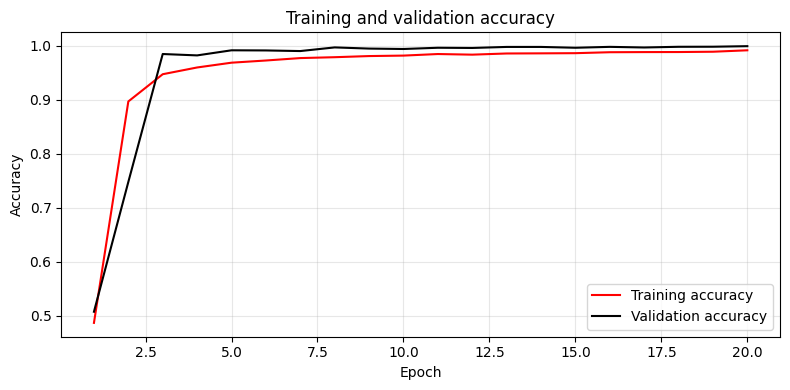

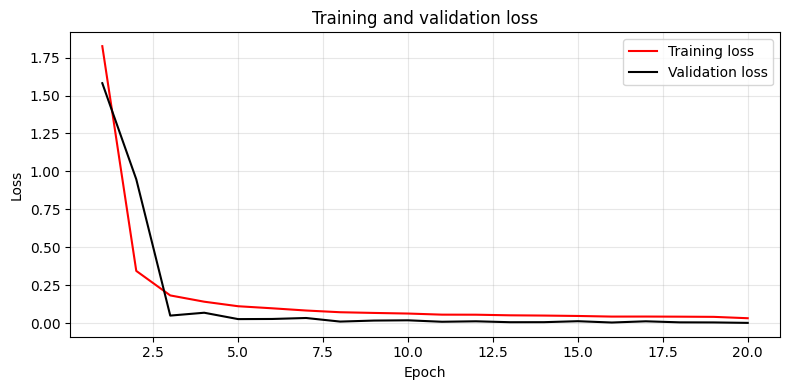

In [36]:
def plot_training_history(history):
    """
    This function plots training and validation accuracy/loss curves.
    We used the in the report to check convergence, training stability and possible overfitting.
    """
    history_df = pd.DataFrame(history.history)
    epochs = np.arange(1, len(history_df) + 1)

    # Accuracy curve
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy", color='red')
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy", color = 'black')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history_df["loss"], label="Training loss", color= 'red')
    plt.plot(epochs, history_df["val_loss"], label="Validation loss", color = 'black')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_training_history(history)

### Curve Interpretation

The accuracy curves increase rapidly during the first epochs and then stabilize, indicating fast convergence. The validation accuracy remains close to the training accuracy, which suggests that the model does not suffer from severe overfitting.

The loss curves decrease consistently and remain low after convergence. Since the validation loss does not diverge from the training loss, the final model appears well regularized.

## 10. Final Test Evaluation

After selecting the final model using validation performance, the model is evaluated once on the test set ( the test set taken from the kaggle competition).

This final evaluation reports:
- **Test accuracy**, measuring the overall percentage of correct predictions
- **Macro F1-score**, giving equal importance to all classes
- **Weighted F1-score**, accounting for the class distribution
- A **classification report**, showing precision, recall and F1-score for each class

Macro F1 is especially important because the GTSRB dataset is imbalanced. It helps verify that the model performs well not only on frequent classes, but also on less represented traffic signs.

The test set is not used for model selection, which keeps the final evaluation fair.

In [37]:
def predict_classes(model, X):
    """
    This function role is to predict class indices and class probabilities.
    Its parameters are:
        model: Trained Keras model
        X: input images
    Its returns:
        y_pred: predicted class indices
        y_prob: softmax probabilities
    """
    y_prob = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    return y_pred, y_prob


def evaluate_final_model(model, X_test, y_test, class_names):
    """
    This function help us evaluate the final selected model on the test set.
    The test set is used only after model selection to estimate final
    generalization performance.
    Its parameters are:
        model: trained Keras model
        X_test: test images
        y_test: integer-encoded test labels
        class_names: class names indexed by class ID
    Its returns are:
        y_pred: predicted class indices
        y_prob: predicted class probabilities
        results: summary of final metrics
    """
    class_names = [str(name) for name in class_names]

    y_pred, y_prob = predict_classes(model, X_test)

    test_accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    results = pd.DataFrame([{
        "Model": "Final compact VGG-style CNN",
        "Parameters": model.count_params(),
        "Test Accuracy": test_accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }])

    print("Final test results")
    display(results.round(4))

    print("\nClassification report")
    print(classification_report(
        y_test,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    ))

    return y_pred, y_prob, results


y_pred, y_prob, final_results = evaluate_final_model(
    model=model,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names
)

Final test results


,Model,Parameters,Test Accuracy,Macro F1,Weighted F1
0,Final compact VGG-style CNN,457547,0.9841,0.9674,0.9838



Classification report
                      precision    recall  f1-score   support

    Speed limit (20)       0.97      1.00      0.98        60
    Speed limit (30)       0.98      1.00      0.99       720
    Speed limit (50)       1.00      1.00      1.00       750
    Speed limit (60)       0.98      0.97      0.98       450
    Speed limit (70)       1.00      1.00      1.00       660
    Speed limit (80)       0.98      0.98      0.98       630
 End speed limit(80)       1.00      0.91      0.95       150
   Speed limit (100)       0.97      1.00      0.98       450
   Speed limit (120)       1.00      0.99      0.99       450
          No passing       0.98      1.00      0.99       480
    No passing >3.5t       1.00      1.00      1.00       660
        Right-of-way       1.00      0.99      1.00       420
       Priority road       1.00      1.00      1.00       690
               Yield       1.00      1.00      1.00       720
                Stop       0.98      1.00     

### Final Evaluation Interpretation

The final VGG-style CNN achieves strong test performance, with high accuracy and high F1-scores. The weighted F1-score is close to the test accuracy, showing that the model performs well on the most frequent classes.

The macro F1-score is slightly lower, which is expected because some minority or visually similar traffic sign classes are harder to classify. This confirms the importance of reporting class-balanced metrics instead of relying only on accuracy.

Overall, the final test results show that the selected compact CNN generalizes well while remaining computationally efficient.

## 11. Confusion Matrix

A normalized confusion matrix is used to analyze the remaining classification errors of the final model.

Rows correspond to the true classes, while columns correspond to the predicted classes. The matrix is normalized by true class, so each row sums to 1. This makes errors easier to compare across classes, even when the dataset is imbalanced.

This diagnostic is important because overall accuracy can hide class-specific weaknesses. In traffic sign classification, many mistakes occur between visually similar signs, such as signs with the same shape and color but different internal symbols or speed-limit digits.

A strong model should show:
- A clear diagonal pattern, indicating correct predictions
- Low off-diagonal values, indicating few systematic confusions
- No large error blocks between specific groups of classes

The confusion matrix therefore provides a more detailed view of model behavior than aggregate metrics alone.

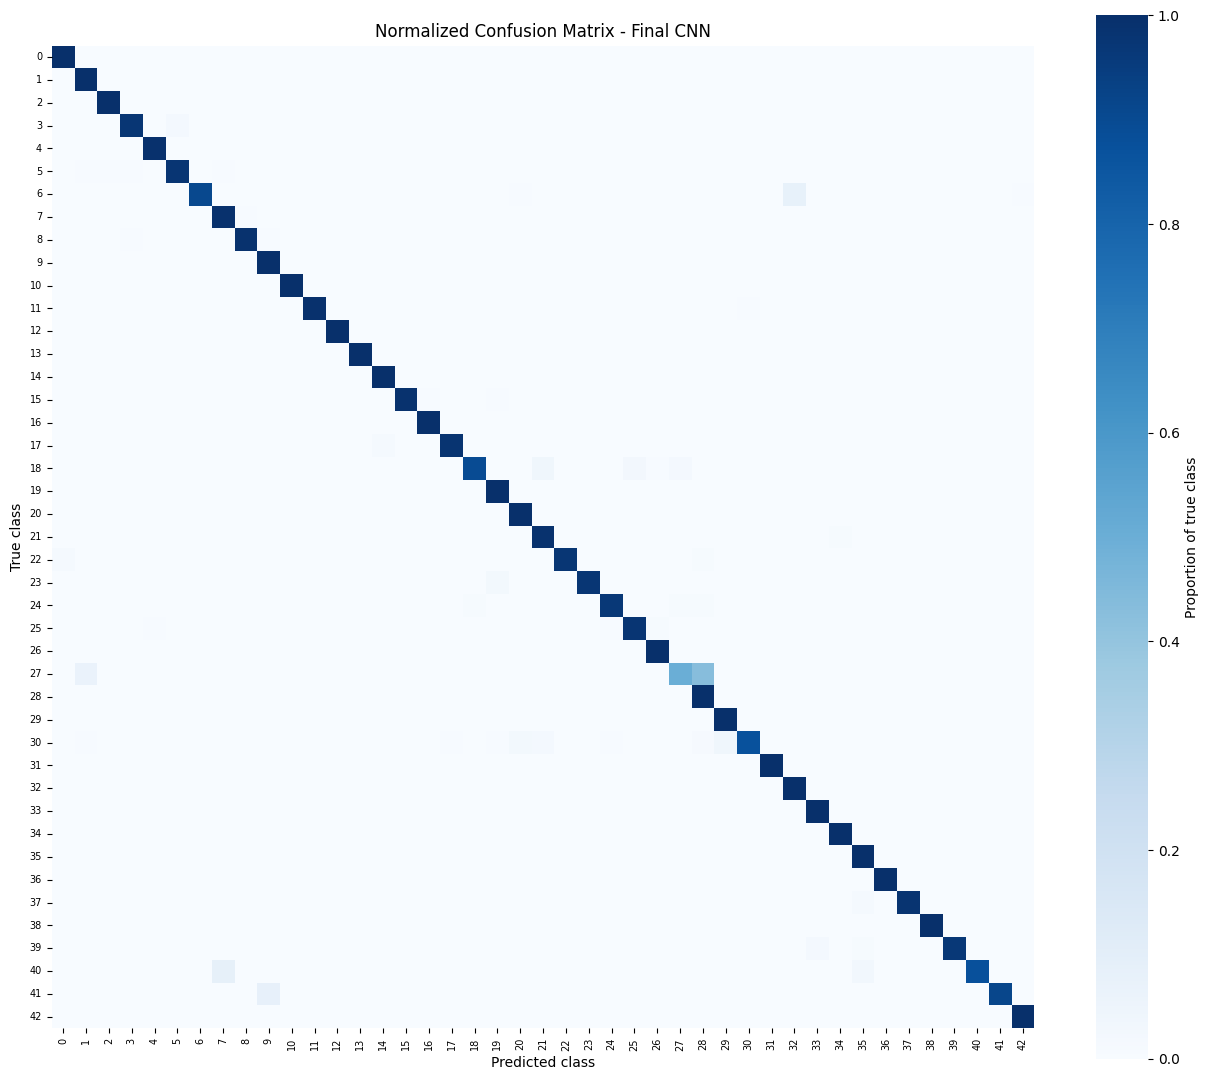

In [38]:
def plot_normalized_confusion_matrix(y_true, y_pred, class_names):
    """
    This function help us plot a row-normalized confusion matrix.
    Each row corresponds to one true class and sums to 1.
    This makes class-wise errors easier to interpret, especially
    when the dataset is imbalanced.
    """
    class_names = [str(name) for name in class_names]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        normalize="true"
    )

    plt.figure(figsize=(13, 11))
    sns.heatmap(
        cm,
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar_kws={"label": "Proportion of true class"}
    )

    plt.title("Normalized Confusion Matrix - Final CNN")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(
        ticks=np.arange(len(class_names)) + 0.5,
        labels=range(len(class_names)),
        rotation=90,
        fontsize=7
    )
    plt.yticks(
        ticks=np.arange(len(class_names)) + 0.5,
        labels=range(len(class_names)),
        rotation=0,
        fontsize=7
    )
    plt.tight_layout()
    plt.show()


plot_normalized_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    class_names=class_names
)

### Confusion Matrix Interpretation

The matrix is strongly diagonal, confirming that the final CNN correctly classifies most traffic signs. The few visible off-diagonal cells correspond to residual errors between visually similar classes.

This is consistent with the class-wise F1-scores: the model performs very well overall, but some classes remain harder because they differ only by small visual details, such as digits, arrows, or internal symbols.

Overall, the confusion matrix confirms that the model does not suffer from broad systematic confusion across many classes. Its remaining errors are localized and visually interpretable.

## 12. Error Analysis

The confusion matrix gives a global view of model behavior, but the most frequent wrong predictions provide a more concrete diagnosis of the remaining errors.

This section extracts all off-diagonal entries from the confusion matrix, meaning cases where the predicted class differs from the true class. The resulting table ranks the most common confusion pairs.

This analysis is useful because it identifies:
- Which classes are most often confused
- Whether errors are concentrated in visually similar signs
- Whether the model has systematic weaknesses rather than random mistakes

In [39]:
def get_wrong_predictions(y_true, y_pred, class_names, top_n=15):
    """
    This function extracts the most frequent wrong prediction pairs from the confusion matrix.
    We decide that only off-diagonal entries are kept, because diagonal entries correspond to correct predictions.
    Its parameters:
        y_true: true class labels
        y_pred: predicted class labels
        class_names: class names indexed by class ID
        top_n: number of most frequent errors to return

    Its single return is a:
        pd.DataFrame: ranked table of most common confusion pairs
    """
    class_names = [str(name) for name in class_names]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(class_names)))
    )

    rows = []

    for actual_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            count = cm[actual_class, predicted_class]

            if actual_class != predicted_class and count > 0:
                rows.append({
                    "Actual Class ID": actual_class,
                    "Predicted Class ID": predicted_class,
                    "Actual Class": class_names[actual_class],
                    "Predicted Class": class_names[predicted_class],
                    "Error Count": int(count)
                })

    wrong_predictions_df = (
        pd.DataFrame(rows)
        .sort_values("Error Count", ascending=False)
        .reset_index(drop=True)
    )

    return wrong_predictions_df.head(top_n)


wrong_predictions_df = get_wrong_predictions(
    y_true=y_test,
    y_pred=y_pred,
    class_names=class_names,
    top_n=15
)

wrong_predictions_df

,Actual Class ID,Predicted Class ID,Actual Class,Predicted Class,Error Count
0,27,28,Pedestrians,Children crossing,26
1,18,21,General caution,Double curve,16
2,6,32,End speed limit(80),End speed+passing,12
3,18,25,General caution,Road work,11
4,3,5,Speed limit (60),Speed limit (80),10
5,18,27,General caution,Pedestrians,9
6,40,7,Roundabout,Speed limit (100),8
7,30,29,Ice/snow,Bicycles crossing,6
8,17,14,No entry,Stop,6
9,25,26,Road work,Traffic signals,5


### Error Analysis Interpretation

The most frequent mistakes are concentrated in a small number of class pairs, which indicates that the model does not fail randomly. Instead, the remaining errors are systematic and mostly occur between visually similar traffic signs.

This is expected for GTSRB because several classes share the same sign shape and color scheme, differing only by small internal details such as digits, arrows, or warning symbols.

Therefore, the error analysis supports the conclusion that the final model has learned the main visual structure of the dataset, while its remaining weaknesses are caused by fine-grained visual distinctions at low image resolution.

## 13. Class-wise Metric Heatmap

Aggregate metrics such as accuracy, macro F1 and weighted F1 summarize overall performance, but they do not show how the model behaves on each individual traffic sign class.

This section computes class-wise:
- **Precision**, measuring how many predictions for a class are correct
- **Recall**, measuring how many true examples of a class are recovered
- **F1-score**, balancing precision and recall
- **Support**, showing the number of test examples per class

The heatmap provides a compact visual summary of class-level performance. It is especially useful for identifying minority or visually similar classes that remain harder to classify.

The table below the heatmap lists the lowest F1-score classes, which helps connect quantitative evaluation with the error-analysis section.

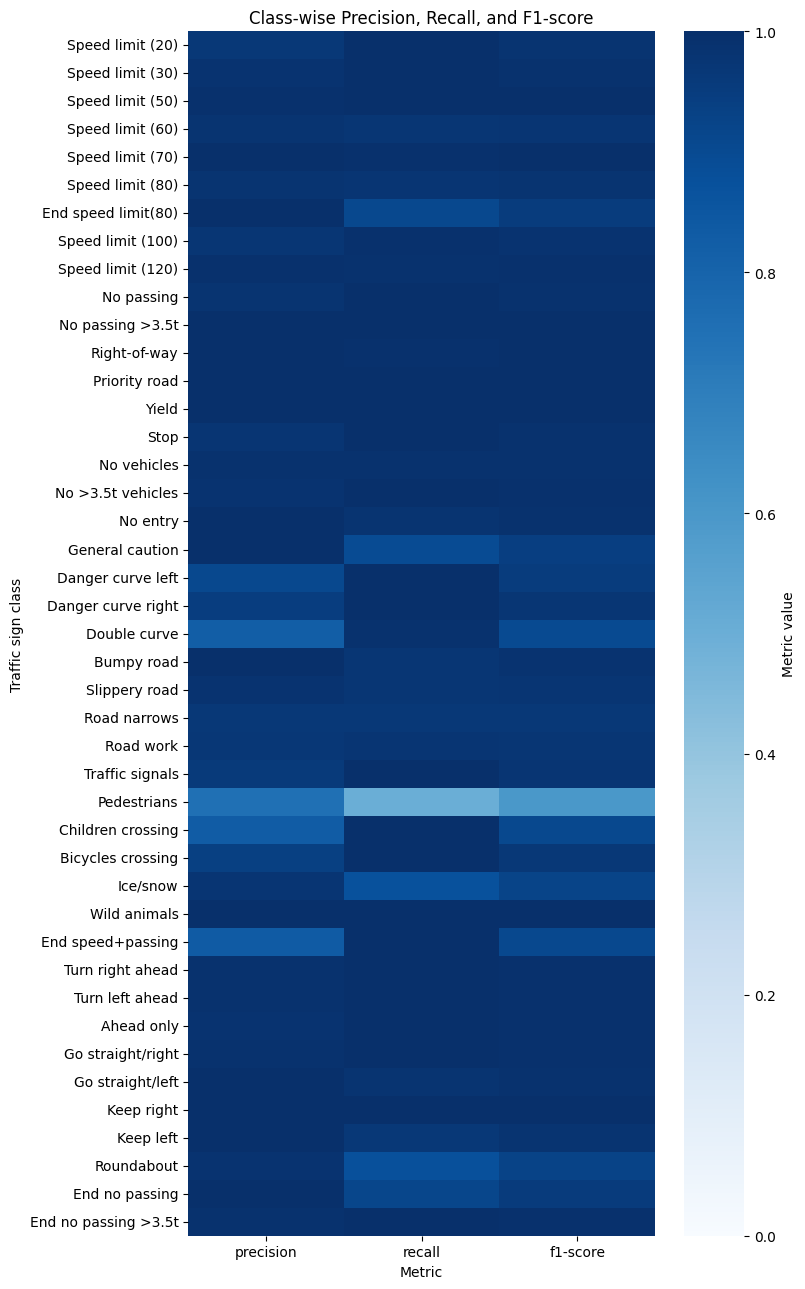

,precision,recall,f1-score,support
Pedestrians,0.750000,0.500000,0.600000,60.0
Double curve,0.824074,0.988889,0.898990,90.0
Children crossing,0.828729,1.000000,0.906344,150.0
End speed+passing,0.833333,1.000000,0.909091,60.0
Ice/snow,0.977612,0.873333,0.922535,150.0
Roundabout,0.987500,0.877778,0.929412,90.0
General caution,0.997151,0.897436,0.944669,390.0
End speed limit(80),1.000000,0.906667,0.951049,150.0
Danger curve left,0.909091,1.000000,0.952381,60.0
End no passing,1.000000,0.916667,0.956522,60.0


In [40]:
def get_classification_report_df(y_true, y_pred, class_names):
    """
    This function convert classification_report output into a clean DataFrame.
    The returned DataFrame contains class-wise precision, recall, F1-score and support for each traffic sign class.
    """
    class_names = [str(name) for name in class_names]

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    # Keep only the real classes, not accuracy/macro avg/weighted avg
    report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]

    return report_df


def plot_classwise_metric_heatmap(report_df):
    """
    This function plots class-wise precision, recall, and F1-score as a heatmap.
    """
    metric_df = report_df[["precision", "recall", "f1-score"]]

    plt.figure(figsize=(8, 13))
    sns.heatmap(
        metric_df,
        annot=False,
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Metric value"}
    )

    plt.title("Class-wise Precision, Recall, and F1-score")
    plt.xlabel("Metric")
    plt.ylabel("Traffic sign class")
    plt.tight_layout()
    plt.show()


report_df = get_classification_report_df(
    y_true=y_test,
    y_pred=y_pred,
    class_names=class_names
)

plot_classwise_metric_heatmap(report_df)

# Show the hardest classes according to F1-score
report_df.sort_values("f1-score").head(10)

### Class-wise Metric Interpretation

Most classes obtain high precision, recall and F1-score, confirming that the final CNN performs consistently across the majority of traffic sign categories.

The lowest F1-score classes correspond to signs that are either underrepresented or visually similar to other classes. This is consistent with the confusion-matrix and error-analysis results, where the remaining mistakes are concentrated in a small number of difficult class pairs.

This confirms that the model has learned the dominant visual patterns in the dataset, while the remaining limitations are mainly caused by fine-grained differences at low image resolution.

## 14. Qualitative Prediction Examples

Quantitative metrics summarize model performance, but visual inspection helps verify whether the predictions are reasonable at the image level.

This section displays a random subset of test images together with:
- The predicted class
- The true class
- The model confidence, defined as the maximum softmax probability

Correct predictions are shown in **green**, while incorrect predictions are shown in **red**. This makes it easier to identify whether mistakes are caused by genuinely difficult images, such as low contrast, blur, unusual lighting, or visually similar traffic signs.

This qualitative check complements the confusion matrix and class-wise metrics by showing concrete examples of the model’s behavior.

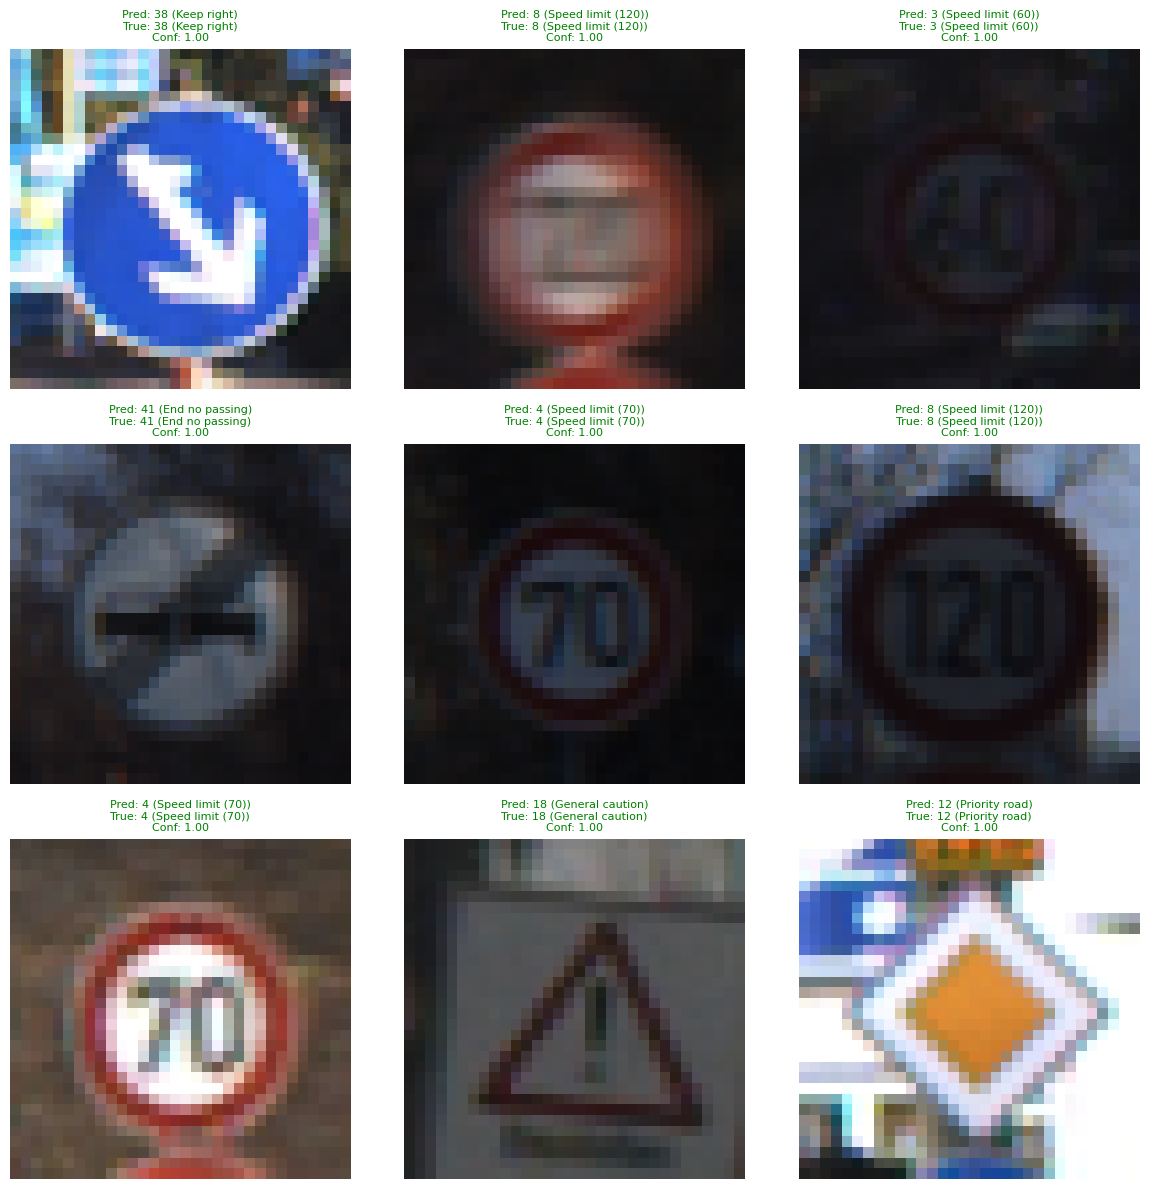

In [41]:
def plot_sample_predictions(X, y_true, y_pred, y_prob, class_names, n=9, seed=SEED):
    """
    This function displays random qualitative prediction examples.
    Correct predictions are shown in green and incorrect predictions in red.
    Confidence is defined as the maximum predicted softmax probability.
    """
    class_names = [str(name) for name in class_names]

    rng = random.Random(seed)
    n = min(n, len(X))
    sample_indices = rng.sample(range(len(X)), n)

    rows = int(np.ceil(n / 3))
    plt.figure(figsize=(12, 4 * rows))

    for plot_index, image_index in enumerate(sample_indices):
        predicted_class = int(y_pred[image_index])
        true_class = int(y_true[image_index])
        confidence = float(np.max(y_prob[image_index]))

        is_correct = predicted_class == true_class
        title_color = "green" if is_correct else "red"

        plt.subplot(rows, 3, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(
            f"Pred: {predicted_class} ({class_names[predicted_class]})\n"
            f"True: {true_class} ({class_names[true_class]})\n"
            f"Conf: {confidence:.2f}",
            color=title_color,
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()
plot_sample_predictions(
    X=X_test,
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
    class_names=class_names,
    n=9
)

### Qualitative Interpretation

Most sampled predictions are correct and have high confidence, which is consistent with the strong quantitative results. The displayed examples also show that the model can correctly classify traffic signs under different lighting and contrast conditions.

When mistakes occur, they should be interpreted together with the confusion matrix and error table.

## 15. Final Summary

This notebook presents a complete and reproducible pipeline for **43-class traffic sign classification** using the GTSRB dataset.

The final model is a VGG-style CNN trained on normalized **32 × 32 RGB images**. It combines convolutional feature extraction, batch normalization, dropout, global average pooling, RMSprop optimization, learning-rate decay and light photometric augmentation.

The final evaluation includes:
- Test accuracy
- Macro F1-score
- Weighted F1-score
- Class-wise precision, recall, and F1-score
- Confusion matrix analysis
- Error analysis
- Qualitative prediction examples

Overall, the results show that a compact and well-regularized CNN can achieve strong performance on cropped traffic sign classification without requiring unnecessary architectural complexity.

In [42]:
final_summary = pd.DataFrame([{
    "Task": "43-class traffic sign classification",
    "Dataset": "GTSRB",
    "Input": "32x32 RGB",
    "Architecture": "Compact VGG-style CNN + global average pooling",
    "Optimizer": "RMSprop",
    "Regularization": "Batch normalization + dropout + light photometric augmentation",
    "Parameters": model.count_params(),
    "Test Accuracy": final_results.loc[0, "Test Accuracy"],
    "Macro F1": final_results.loc[0, "Macro F1"],
    "Weighted F1": final_results.loc[0, "Weighted F1"]
}])

display(final_summary.round({
    "Test Accuracy": 4,
    "Macro F1": 4,
    "Weighted F1": 4
}))

,Task,Dataset,Input,Architecture,Optimizer,Regularization,Parameters,Test Accuracy,Macro F1,Weighted F1
0,43-class traffic sign classification,GTSRB,32x32 RGB,Compact VGG-style CNN + global average pooling,RMSprop,Batch normalization + dropout + light photomet...,457547,0.9841,0.9674,0.9838


### Final Conclusion

The final model achieves high test accuracy and strong F1-scores while remaining compact and computationally efficient. The confusion matrix, error analysis and class-wise metrics show that most remaining mistakes are concentrated in visually similar traffic sign classes.

The main conclusion is that, for this cropped low-resolution GTSRB task, careful preprocessing, regularization and optimization are more important than simply increasing model size. This makes the final CNN a strong and interpretable solution for traffic sign classification.

# Thank You !